In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [2]:
np.random.seed(42)

n = 1000

df = pd.DataFrame({
    "user_id": range(1, n+1),
    "country": np.random.choice(["USA", "Germany", "UK", "France"], n),
    "session_time": np.random.randint(1, 60, n),
    "age": np.random.randint(16, 60, n),
    "device": np.random.choice(["Android", "IOS"], n)
})

purchase_prob = (
    df["session_time"] * 0.02 +
    df["age"] * 0.005 +
    (df["device"] == "IOS") * 0.1
)

df["purchases"] = (purchase_prob > 1).astype(int)

df.head()

,user_id,country,session_time,age,device,purchases
0,1,UK,54,55,Android,1
1,2,France,17,41,IOS,0
2,3,USA,9,38,Android,0
3,4,UK,33,59,IOS,1
4,5,UK,53,54,IOS,1


In [3]:
df.to_csv("full_data_pipeline", index=False)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   user_id       1000 non-null   int64 
 1   country       1000 non-null   object
 2   session_time  1000 non-null   int32 
 3   age           1000 non-null   int32 
 4   device        1000 non-null   object
 5   purchases     1000 non-null   int32 
dtypes: int32(3), int64(1), object(2)
memory usage: 35.3+ KB


In [5]:
df.isna().sum()

user_id         0
country         0
session_time    0
age             0
device          0
purchases       0
dtype: int64

In [6]:
df["session_time"].mean()

30.223

In [7]:
df["purchases"].mean()

0.367

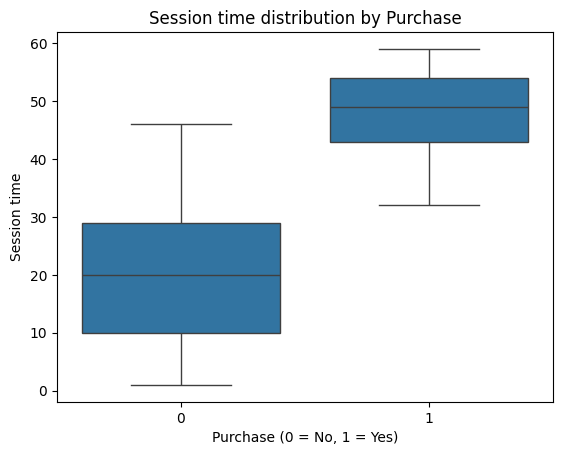

In [14]:
sns.boxplot(x="purchases", y="session_time", data=df)
plt.xlabel("Purchase (0 = No, 1 = Yes)")
plt.ylabel("Session time")
plt.title("Session time distribution by Purchase")
plt.show()

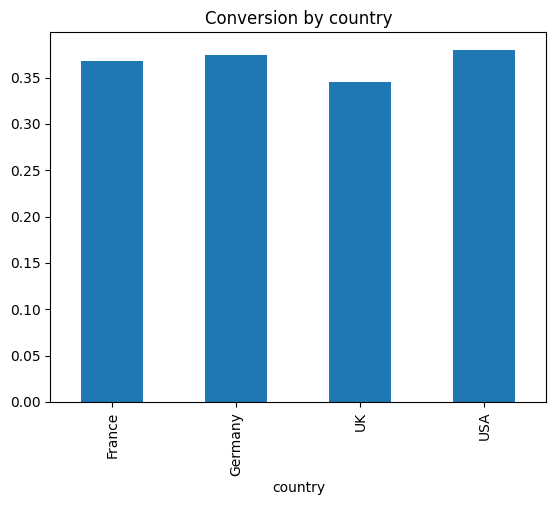

In [15]:
conversion_by_country = df.groupby("country")["purchases"].mean()
conversion_by_country.plot(kind="bar", title="Conversion by country")
plt.show()

In [16]:
df["device"] = df["device"].map({
    "Android": 0,
    "IOS": 1
})

df = pd.get_dummies(df, columns=["country"], drop_first=True)

In [17]:
X = df.drop(["user_id", "purchases"], axis=1)
y = df["purchases"]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [24]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy: ", accuracy_score(y_test, y_pred))

Accuracy:  0.995


In [30]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})
coefficients = coefficients.sort_values(by="Coefficient", ascending=False)
coefficients

,Feature,Coefficient
2,device,4.060652
0,session_time,1.071970
1,age,0.268324
4,country_UK,0.190097
5,country_USA,-0.226817
3,country_Germany,-0.642599


In [31]:
model.coef_

array([[ 1.07197044,  0.26832429,  4.06065197, -0.64259888,  0.19009709,
        -0.22681661]])

In [32]:
df.groupby("device")["purchases"].mean()

device
0    0.320833
1    0.409615
Name: purchases, dtype: float64